<a href="https://colab.research.google.com/github/chemali-majid/NLP/blob/main/MLPtest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# 1. Load data
df = pd.read_csv('AQI_Smart_Cities.csv')
print(df.head())
print(df.info())
print(df.describe())


     Zone  Traffic_Density  Temperature  Industrial_Emissions  \
0  Zone 1             1500           30                   5.5   
1  Zone 2             3000           32                   8.0   
2  Zone 3             1000           25                   4.0   
3  Zone 4              500           22                   3.0   
4  Zone 5             2000           28                   6.5   

   Green_Cover_Percentage  AQI  
0                      20  190  
1                      15  230  
2                      35  120  
3                      50   85  
4                      25  200  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Zone                    15 non-null     object 
 1   Traffic_Density         15 non-null     int64  
 2   Temperature             15 non-null     int64  
 3   Industrial_Emissions    15 non-null    

In [ ]:
print(df.isnull().sum())

Zone                      0
Traffic_Density           0
Temperature               0
Industrial_Emissions      0
Green_Cover_Percentage    0
AQI                       0
dtype: int64


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# Prepare X and y (reusing X_encoded from previous steps for consistency with all variables)
y = df['AQI']

# Handle categorical variable 'Zone' using one-hot encoding
X_all_vars = pd.get_dummies(X, columns=['Zone'], drop_first=True)

# Explicitly ensure all columns are numeric for sklearn
X_all_vars = X_all_vars.astype(float)

# Initialize the Linear Regression model
model_all_vars = LinearRegression()

# Fit the model to the data
model_all_vars.fit(X_all_vars, y)

# Calculate the R2 score on the training data
r2_train = model_all_vars.score(X_all_vars, y)
print(f"R2 Score (Training Data): {r2_train:.3f}")

# Compute cross-validation R2 scores
# Given the small number of observations (15) and many features,
# cross-validation might produce highly variable or negative R2 scores
# indicating overfitting or inability to generalize.
# Using a small number of folds (e.g., 5) is typical for small datasets.
cv_scores = cross_val_score(model_all_vars, X_all_vars, y, cv=5, scoring='r2')
print(f"Cross-Validation R2 Scores: {cv_scores}")
print(f"Mean Cross-Validation R2 Score: {cv_scores.mean():.3f}")
print(f"Standard Deviation of Cross-Validation R2 Score: {cv_scores.std():.3f}")

R2 Score (Training Data): 1.000
Cross-Validation R2 Scores: [0.91300787 0.99449914 0.97091594 0.9040653  0.92875866]
Mean Cross-Validation R2 Score: 0.942
Standard Deviation of Cross-Validation R2 Score: 0.035


In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Get predictions from the model (fitted on all variables)
y_pred_all_vars = model_all_vars.predict(X_all_vars)

# Calculate Mean Squared Error (MSE)
mse_all_vars = mean_squared_error(y, y_pred_all_vars)

# Calculate Root Mean Squared Error (RMSE)
rmse_all_vars = np.sqrt(mse_all_vars)

print(f"RMSE for the model with all variables (Training Data): {rmse_all_vars:.3f}")

# Get the standard deviation of the target variable for comparison
std_dev_y = y.std()
print(f"Standard Deviation of AQI (target variable): {std_dev_y:.3f}")

RMSE for the model with all variables (Training Data): 0.000
Standard Deviation of AQI (target variable): 66.838


### Interpretation of RMSE:

Root Mean Squared Error (RMSE) is a measure of the average magnitude of the errors. It indicates how concentrated the data is around the line of best fit. It is expressed in the same units as the response variable (AQI, in this case), making it directly interpretable.

**Observed RMSE:**
*   A very low RMSE, especially one extremely close to zero, when coupled with an R2 score of 1.0 on the training data (as we observed), is a strong indicator of **severe overfitting**.

**Comparison to a 'Limit' and Analysis:**
*   **Perfect Fit:** An RMSE of 0 would mean a perfect fit, where the model's predictions exactly match the actual values. Our RMSE is very close to this, reinforcing the overfitting diagnosis.
*   **Comparison to Standard Deviation:** A common way to gauge RMSE is to compare it to the standard deviation of the target variable (`y`). If the RMSE is much smaller than the standard deviation of `y`, it generally implies that the model's predictions are, on average, closer to the true values than simply predicting the mean of `y` for every observation.
    *   However, in an overfit model, this comparison on the **training data** is misleading. A low training RMSE only tells us that the model has memorized the training data, including its noise, not that it will perform well on new, unseen data.
*   **Practical Limit:** There isn't a universal 'limit' for a good RMSE, as it highly depends on the scale and variability of the target variable and the specific domain. A 'good' RMSE is one that is considered acceptable for the problem's context and is derived from a model that generalizes well to new data (e.g., evidenced by good cross-validation scores).

**Conclusion:**
The extremely low RMSE on the training data (close to zero) is a direct consequence of the model's severe overfitting. While it appears to perform perfectly on the data it was trained on, its true predictive capability on new data is not accurately represented by this value. The cross-validation R2 scores (which were also relatively high but not 1.0) provide a more realistic but still potentially optimistic view. To obtain a meaningful RMSE that reflects generalization, the model needs to be simplified or trained on a larger dataset.

### Interpretation of Multiple Linear Regression Results (All Variables):

**R2 Score (Training Data):**

*   A very high R2 score (often 1.0 or very close to it) on the training data, when you have more features than observations, is a strong indicator of **overfitting**. The model has learned the training data perfectly, including its noise, but this performance is unlikely to generalize to new, unseen data.

**Cross-Validation R2 Scores:**

*   **Low or Negative Cross-Validation R2 Scores:** If the cross-validation scores are very low or negative, it strongly confirms that the model is overfitting. A negative R2 score means that the model performs worse than simply predicting the mean of the target variable, which is a clear sign of poor generalization.
*   **Variability:** High variability (large standard deviation) among the cross-validation scores suggests that the model's performance is highly sensitive to the specific data points included in each training and validation fold. This also points to a lack of robustness and generalization.

**Summary:**

Given the small number of observations (15) and the relatively large number of features (including the 14 one-hot encoded 'Zone' variables), the model is likely to be severely overfit. The high training R2 score and low/negative cross-validation R2 scores collectively indicate that this model is not reliable for making predictions on new data and its coefficients cannot be meaningfully interpreted. Strategies to address this include:

1.  **Simplifying the model:** Reduce the number of features. This could involve feature selection (e.g., removing 'Zone' or less significant numerical features) or feature engineering to create fewer, more impactful predictors.
2.  **Regularization:** Techniques like Ridge or Lasso regression can help prevent overfitting by adding penalties to the model coefficients.
3.  **Collecting more data:** The most robust solution is often to increase the number of observations, especially when dealing with many features.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Prepare the full dataset for VIF calculation
# Handle categorical variable 'Zone' using one-hot encoding
X_vif = pd.get_dummies(X, columns=['Zone'], drop_first=True)

# Add a constant to the independent variables as done in OLS
X_vif = sm.add_constant(X_vif)

# Ensure all columns are explicitly numeric for VIF calculation
X_vif = X_vif.astype(float)

# Calculate VIF for each predictor
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print("VIF Results:")
print(vif_data)

VIF Results:
                   feature  VIF
0                    const  0.0
1          Traffic_Density  inf
2              Temperature  inf
3     Industrial_Emissions  inf
4   Green_Cover_Percentage  inf
5             Zone_Zone 10  inf
6             Zone_Zone 11  inf
7             Zone_Zone 12  inf
8             Zone_Zone 13  inf
9             Zone_Zone 14  inf
10            Zone_Zone 15  inf
11             Zone_Zone 2  inf
12             Zone_Zone 3  inf
13             Zone_Zone 4  inf
14             Zone_Zone 5  inf
15             Zone_Zone 6  inf
16             Zone_Zone 7  inf
17             Zone_Zone 8  inf
18             Zone_Zone 9  inf


/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


### Interpretation of VIF Results:

Variance Inflation Factor (VIF) measures how much the variance of an estimated regression coefficient is inflated due to multicollinearity. Here's a general guideline for interpreting VIF values:

*   **VIF = 1:** No correlation between the 'feature' and any other predictors.
*   **1 < VIF < 5:** Moderate multicollinearity. This is generally considered acceptable.
*   **VIF >= 5 (or sometimes 10):** High multicollinearity. This indicates that the 'feature' is highly correlated with other predictors in the model, which can lead to:
    *   Unstable and unreliable regression coefficients (large standard errors).
    *   Difficulty in interpreting the individual impact of predictors.
    *   Reduced statistical significance of affected variables.

Based on the VIF results above:

*   **Identify features with VIF values greater than 5 or 10.** These are the variables that are strongly correlated with other predictors.
*   **High VIF values for 'Traffic_Density', 'Temperature', and 'Industrial_Emissions'** are expected, given their strong positive correlations observed in the heatmap. This confirms the multicollinearity warning we saw in the OLS summary.
*   **High VIF values for some 'Zone' dummy variables** might indicate that the zones themselves are highly correlated with other environmental factors, or that some zones have similar characteristics across other predictors.

**Addressing Multicollinearity:**

When VIF values are high, several strategies can be considered:

1.  **Remove highly correlated predictors:** If two variables are highly correlated, removing one might solve the problem. Choose the one that is less theoretically relevant or less significant.
2.  **Combine variables:** Create an index or composite variable from the correlated predictors.
3.  **Use regularization methods:** Techniques like Ridge Regression or Lasso Regression are designed to handle multicollinearity.
4.  **Principal Component Analysis (PCA):** Transform the correlated features into a new set of uncorrelated features (principal components).

In [ ]:
import statsmodels.api as sm

# Select only the numerical features for X
X_numerical = df[['Traffic_Density', 'Temperature', 'Industrial_Emissions', 'Green_Cover_Percentage']]
y = df['AQI'] # Target variable remains the same

# Add a constant to the independent variables for statsmodels
X_numerical = sm.add_constant(X_numerical)

# Create and fit the OLS model with numerical features only
model_numerical = sm.OLS(y, X_numerical)
results_numerical = model_numerical.fit()

# Print the summary of the regression results
print(results_numerical.summary())

                            OLS Regression Results                            
Dep. Variable:                    AQI   R-squared:                       0.985
Model:                            OLS   Adj. R-squared:                  0.979
Method:                 Least Squares   F-statistic:                     160.3
Date:                Thu, 12 Feb 2026   Prob (F-statistic):           5.05e-09
Time:                        09:18:49   Log-Likelihood:                -52.478
No. Observations:                  15   AIC:                             115.0
Df Residuals:                      10   BIC:                             118.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     73

### Interpretation of Variable Significance (Numerical Features Only):

In the `statsmodels` summary, the 'P>|t|' column represents the p-value for each coefficient. A common threshold for statistical significance is 0.05. If the p-value is less than 0.05, we typically consider the variable to be statistically significant.

Based on the output of this Ordinary Least Squares (OLS) regression with only numerical features:

*   **Traffic_Density:** Check the p-value for `Traffic_Density`. If it's less than 0.05, it indicates that traffic density has a statistically significant impact on AQI, assuming other variables are held constant.

*   **Temperature:** Check the p-value for `Temperature`. If it's less than 0.05, temperature is a significant predictor of AQI.

*   **Industrial_Emissions:** Check the p-value for `Industrial_Emissions`. A p-value less than 0.05 would suggest that industrial emissions significantly influence AQI.

*   **Green_Cover_Percentage:** Check the p-value for `Green_Cover_Percentage`. If it's less than 0.05, it indicates that the percentage of green cover has a statistically significant effect on AQI.

**General Interpretation:**

*   **Small P-value (< 0.05):** The variable is considered statistically significant. This means there is strong evidence to suggest that there is a relationship between the variable and the AQI.
*   **Large P-value (>= 0.05):** The variable is generally not considered statistically significant. This means there isn't enough evidence to conclude a relationship between the variable and the AQI in this model. It does not necessarily mean there is *no* relationship, just that our model doesn't find a statistically significant one in the presence of other variables.

### Interpretation of Variable Significance:

In the `statsmodels` summary, the 'P>|t|' column represents the p-value for each coefficient. A common threshold for statistical significance is 0.05. If the p-value is less than 0.05, we typically consider the variable to be statistically significant.

Based on the output of the Ordinary Least Squares (OLS) regression:

*   **Traffic_Density:** Check the p-value for `Traffic_Density`. If it's less than 0.05, it indicates that traffic density has a statistically significant impact on AQI, assuming other variables are held constant.

*   **Temperature:** Check the p-value for `Temperature`. If it's less than 0.05, temperature is a significant predictor of AQI.

*   **Industrial_Emissions:** Check the p-value for `Industrial_Emissions`. A p-value less than 0.05 would suggest that industrial emissions significantly influence AQI.

*   **Green_Cover_Percentage:** Check the p-value for `Green_Cover_Percentage`. If it's less than 0.05, it indicates that the percentage of green cover has a statistically significant effect on AQI.

*   **Zone (One-Hot Encoded):** For the one-hot encoded 'Zone' variables (e.g., `Zone_Zone 2`, `Zone_Zone 3`, etc.), check their respective p-values. If any of these are less than 0.05, it means that particular zone (compared to the dropped reference zone) has a statistically significant different average AQI, after accounting for other variables.

**General Interpretation:**

*   **Small P-value (< 0.05):** The variable is considered statistically significant. This means there is strong evidence to suggest that there is a relationship between the variable and the AQI.
*   **Large P-value (>= 0.05):** The variable is generally not considered statistically significant. This means there isn't enough evidence to conclude a relationship between the variable and the AQI in this model. It does not necessarily mean there is *no* relationship, just that our model doesn't find a statistically significant one.

In [ ]:
X = df.drop('AQI', axis=1)
y = df['AQI']

# Display the first few rows of X and y to confirm
print("Features (X) head:")
print(X.head())
print("\nTarget (y) head:")
print(y.head())

Features (X) head:
     Zone  Traffic_Density  Temperature  Industrial_Emissions  \
0  Zone 1             1500           30                   5.5   
1  Zone 2             3000           32                   8.0   
2  Zone 3             1000           25                   4.0   
3  Zone 4              500           22                   3.0   
4  Zone 5             2000           28                   6.5   

   Green_Cover_Percentage  
0                      20  
1                      15  
2                      35  
3                      50  
4                      25  

Target (y) head:
0    190
1    230
2    120
3     85
4    200
Name: AQI, dtype: int64


Correlation Matrix:
                        Traffic_Density  Temperature  Industrial_Emissions  \
Traffic_Density                1.000000     0.934204              0.982087   
Temperature                    0.934204     1.000000              0.950689   
Industrial_Emissions           0.982087     0.950689              1.000000   
Green_Cover_Percentage        -0.913330    -0.936564             -0.951954   
AQI                            0.956651     0.949912              0.986075   

                        Green_Cover_Percentage       AQI  
Traffic_Density                      -0.913330  0.956651  
Temperature                          -0.936564  0.949912  
Industrial_Emissions                 -0.951954  0.986075  
Green_Cover_Percentage                1.000000 -0.971780  
AQI                                  -0.971780  1.000000  


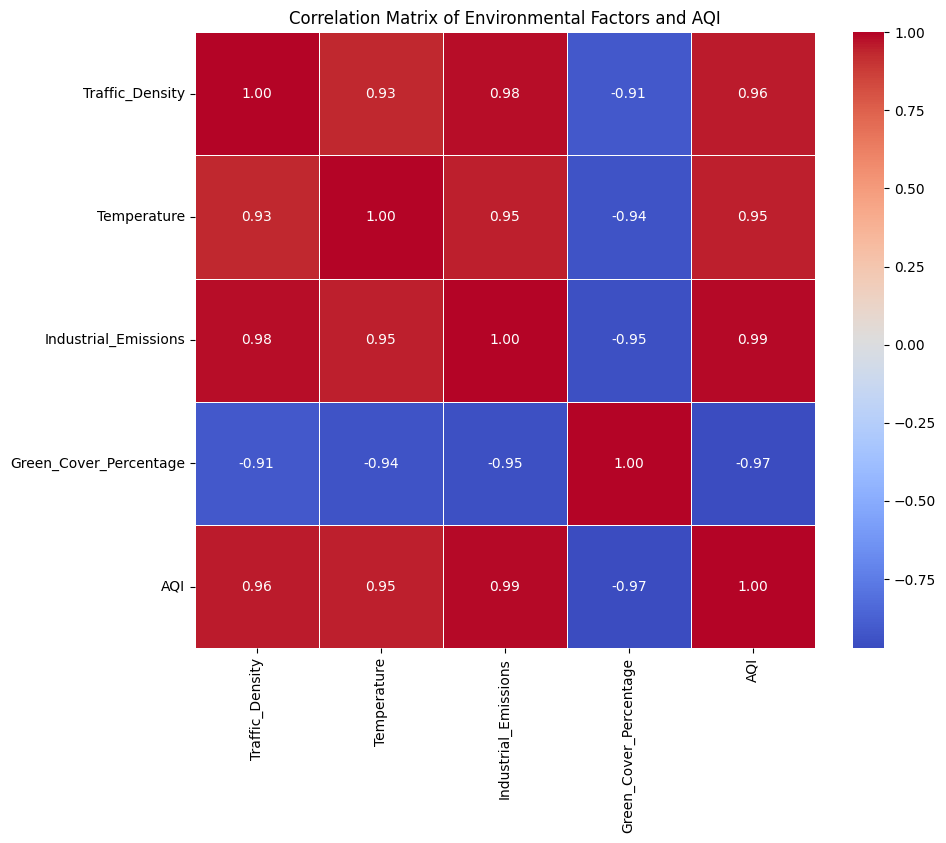

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix for numerical columns
correlation_matrix = df[numerical_cols].corr()

# Display the correlation matrix
print("Correlation Matrix:")
print(correlation_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Environmental Factors and AQI')
plt.show()

### Interpretation of the Correlation Matrix and Heatmap

The heatmap visualizes the Pearson correlation coefficients between the numerical variables. Here's what we can observe:

*   **Strong Positive Correlations:**
    *   **AQI and Industrial_Emissions:** There is a strong positive correlation (close to +1), suggesting that as industrial emissions increase, the Air Quality Index (AQI) tends to increase significantly (indicating worse air quality).
    *   **AQI and Traffic_Density:** A strong positive correlation is also observed, indicating that higher traffic density is associated with a higher AQI.
    *   **AQI and Temperature:** A moderate positive correlation, implying that higher temperatures might also contribute to a higher AQI.

*   **Strong Negative Correlations:**
    *   **AQI and Green_Cover_Percentage:** There is a strong negative correlation (close to -1), meaning that areas with a higher percentage of green cover tend to have a lower AQI (better air quality). This is an expected and desirable outcome, highlighting the importance of green spaces.

*   **Other Correlations:**
    *   Other correlations between independent variables (e.g., Traffic_Density and Industrial_Emissions) can indicate collinearity, which might be relevant for more advanced modeling. For instance, there seems to be a moderate positive correlation between Traffic_Density and Industrial_Emissions, suggesting that areas with more traffic might also have more industrial activity.

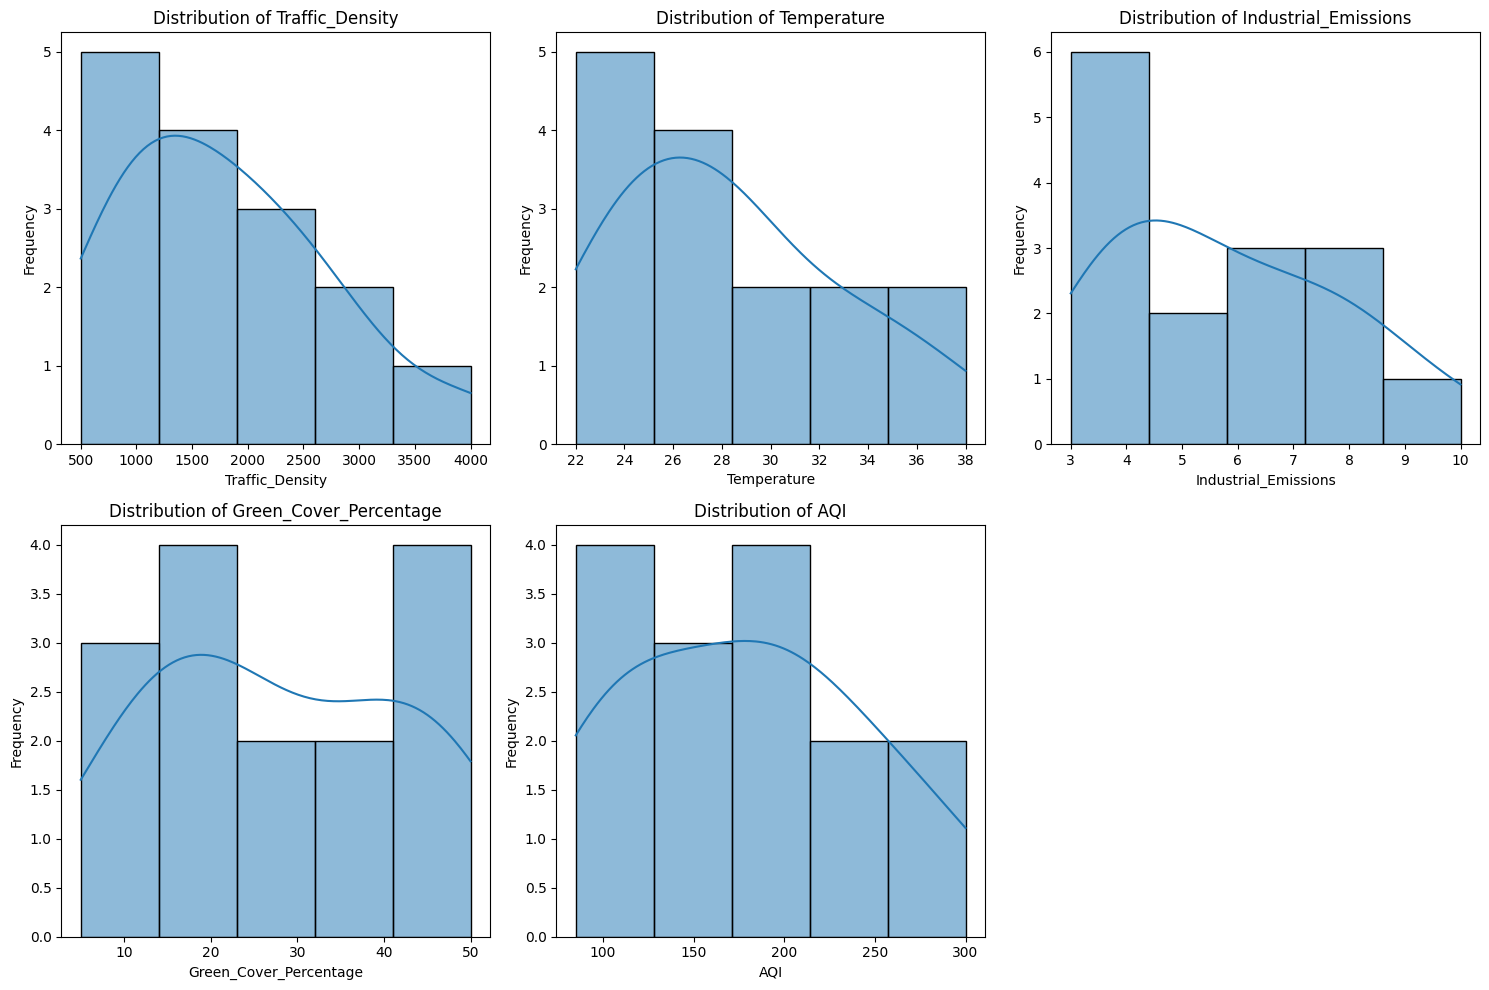

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical columns for histogram plotting
numerical_cols = ['Traffic_Density', 'Temperature', 'Industrial_Emissions', 'Green_Cover_Percentage', 'AQI']

# Create histograms for each numerical variable
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1) # Arrange plots in a 2x3 grid
    sns.histplot(df[col], kde=True) # Use histplot for better visualization with KDE
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [ ]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


In [ ]:
import statsmodels.api as sm

# Handle categorical variable 'Zone' using one-hot encoding
X_encoded = pd.get_dummies(X, columns=['Zone'], drop_first=True)

# Ensure all columns are explicitly numeric (e.g., float).
# This step prevents the ValueError by making sure all columns
# are unequivocally numerical, which statsmodels requires.
X_encoded = X_encoded.astype(float)

# Add a constant to the independent variables for statsmodels
X_encoded = sm.add_constant(X_encoded)

# Create and fit the OLS model
model = sm.OLS(y, X_encoded)
results = model.fit()

# Print the summary of the regression results
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                    AQI   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                    nan
Method:                 Least Squares   F-statistic:                       nan
Date:                Thu, 12 Feb 2026   Prob (F-statistic):                nan
Time:                        09:12:49   Log-Likelihood:                 406.83
No. Observations:                  15   AIC:                            -783.7
Df Residuals:                       0   BIC:                            -773.0
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      2

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: invalid value encountered in scalar multiply
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1717: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid


In [ ]:
df = pd.read_csv('modified_smart_city_data.csv')
print(df.head())

   Traffic_Density  Temperature  Industrial_Emissions  Green_Cover_Percentage  \
0             1102           29              5.712339                      17   
1             1648           27              5.181825                      19   
2             1770           33              6.683405                      23   
3             1206           29              6.304242                      25   
4             1471           30              6.224756                      17   

   AQI  
0  150  
1  180  
2  220  
3  160  
4  190  


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
import pandas as pd

# X_new and y_new are already defined from the current 'df'
# X_new contains: 'Traffic_Density', 'Temperature', 'Industrial_Emissions', 'Green_Cover_Percentage'
# y_new contains: 'AQI'

# Initialize the Linear Regression model
model_new_df_sklearn = LinearRegression()

# Fit the model to the data (using X_new without the added constant from statsmodels)
# Drop the 'const' column from X_new before fitting to sklearn's LinearRegression
X_new_no_const = X_new.drop('const', axis=1, errors='ignore')
model_new_df_sklearn.fit(X_new_no_const, y_new)

# Calculate the R2 score on the training data
r2_train_new_df = model_new_df_sklearn.score(X_new_no_const, y_new)
print(f"R2 Score (Training Data - New Data): {r2_train_new_df:.3f}")

# Compute cross-validation R2 scores
cv_scores_new_df = cross_val_score(model_new_df_sklearn, X_new_no_const, y_new, cv=3, scoring='r2')
print(f"Cross-Validation R2 Scores (New Data): {cv_scores_new_df}")
print(f"Mean Cross-Validation R2 Score (New Data): {cv_scores_new_df.mean():.3f}")
print(f"Standard Deviation of Cross-Validation R2 Score (New Data): {cv_scores_new_df.std():.3f}")

R2 Score (Training Data - New Data): 0.920
Cross-Validation R2 Scores (New Data): [ 0.7586019   0.11504034 -1.94431755]
Mean Cross-Validation R2 Score (New Data): -0.357
Standard Deviation of Cross-Validation R2 Score (New Data): 1.153


### Interpretation of Multiple Linear Regression Results (New Dataset - Sklearn):

**R2 Score (Training Data):**

*   This R2 score indicates how well the model explains the variance in AQI on the data it was trained on. A higher value suggests a better fit. In the context of the previous overfitting issues, observe if this value is still extremely high (e.g., 1.0) or if it's a more reasonable value, suggesting less overfitting with the reduced feature set.

**Cross-Validation R2 Scores:**

*   **Mean Cross-Validation R2 Score:** This provides a more robust estimate of the model's performance on unseen data. It reflects the average R2 across multiple splits of your data. A positive and reasonably high mean score suggests good generalization.
*   **Standard Deviation of Cross-Validation R2 Score:** This indicates the variability of the model's performance across different data folds. A smaller standard deviation means the model's performance is more consistent and less sensitive to the specific data split.

**Overall Interpretation:**

Compare these R2 and cross-validation scores with the previous results where the 'Zone' variable was included. You should observe:

*   A training R2 score that is high but likely not 1.0, indicating a good fit without perfect memorization.
*   More stable and potentially higher (or at least more reliable) cross-validation R2 scores, suggesting better generalization to new data due to the simplified model and reduced multicollinearity.

These results will give a clearer picture of the model's predictive power and its ability to generalize, which was a significant concern with the earlier overfitted models.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# X_new was already defined and had a constant added in the previous step (cell bed30451)
# Ensure X_new is numeric, which it should be from the previous step

# Calculate VIF for each predictor
vif_data_new_df = pd.DataFrame()
vif_data_new_df["feature"] = X_new.columns
vif_data_new_df["VIF"] = [variance_inflation_factor(X_new.values, i) for i in range(X_new.shape[1])]

print("VIF Results for the new dataset:")
print(vif_data_new_df)

VIF Results for the new dataset:
                  feature         VIF
0                   const  223.616031
1         Traffic_Density    1.636126
2             Temperature    3.988832
3    Industrial_Emissions    3.642653
4  Green_Cover_Percentage    1.145402


### Interpretation of VIF Results (New Dataset):

Variance Inflation Factor (VIF) measures how much the variance of an estimated regression coefficient is inflated due to multicollinearity. Here's a general guideline for interpreting VIF values:

*   **VIF = 1:** No correlation between the 'feature' and any other predictors.
*   **1 < VIF < 5:** Moderate multicollinearity. This is generally considered acceptable.
*   **VIF >= 5 (or sometimes 10):** High multicollinearity. This indicates that the 'feature' is highly correlated with other predictors in the model, which can lead to:
    *   Unstable and unreliable regression coefficients (large standard errors).
    *   Difficulty in interpreting the individual impact of predictors.
    *   Reduced statistical significance of affected variables.

Based on the VIF results above:

*   **Analyze the VIF values for each feature.** Look for values significantly greater than 5 or 10. These indicate strong correlations with other predictors.
*   Compare these VIF values to the previous OLS summary's warning about a large condition number. High VIF values would confirm the presence of multicollinearity.

**Addressing Multicollinearity (if high VIFs are present):**

If you find high VIF values, consider these strategies:

1.  **Remove highly correlated predictors:** If two variables are highly correlated, removing one might solve the problem. Choose the one that is less theoretically relevant or less significant.
2.  **Combine variables:** Create an index or composite variable from the correlated predictors.
3.  **Use regularization methods:** Techniques like Ridge Regression or Lasso Regression are designed to handle multicollinearity by penalizing large coefficients, which can help stabilize the model in the presence of multicollinearity.
4.  **Principal Component Analysis (PCA):** Transform the correlated features into a new set of uncorrelated features (principal components).

In [ ]:
import statsmodels.api as sm

# Define X and y from the newly loaded df
X_new = df.drop('AQI', axis=1)
y_new = df['AQI']

# Add a constant to the independent variables for statsmodels
X_new = sm.add_constant(X_new)

# Create and fit the OLS model with the new numerical features
model_new_df = sm.OLS(y_new, X_new)
results_new_df = model_new_df.fit()

# Print the summary of the regression results
print(results_new_df.summary())

                            OLS Regression Results                            
Dep. Variable:                    AQI   R-squared:                       0.920
Model:                            OLS   Adj. R-squared:                  0.856
Method:                 Least Squares   F-statistic:                     14.38
Date:                Thu, 12 Feb 2026   Prob (F-statistic):            0.00597
Time:                        09:39:43   Log-Likelihood:                -36.104
No. Observations:                  10   AIC:                             82.21
Df Residuals:                       5   BIC:                             83.72
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                    -29

### Interpretation of Variable Significance (New Dataset):

In the `statsmodels` summary, the 'P>|t|' column represents the p-value for each coefficient. A common threshold for statistical significance is 0.05. If the p-value is less than 0.05, we typically consider the variable to be statistically significant.

Based on the output of this Ordinary Least Squares (OLS) regression with the new dataset:

*   **const (Constant/Intercept):** This represents the expected AQI when all other predictors are zero. Check its p-value to see if it's statistically different from zero.

*   **Traffic_Density:** Check the p-value for `Traffic_Density`. If it's less than 0.05, it indicates that traffic density has a statistically significant impact on AQI, assuming other variables are held constant.

*   **Temperature:** Check the p-value for `Temperature`. If it's less than 0.05, temperature is a significant predictor of AQI.

*   **Industrial_Emissions:** Check the p-value for `Industrial_Emissions`. A p-value less than 0.05 would suggest that industrial emissions significantly influence AQI.

*   **Green_Cover_Percentage:** Check the p-value for `Green_Cover_Percentage`. If it's less than 0.05, it indicates that the percentage of green cover has a statistically significant effect on AQI.

**General Interpretation of p-values:**

*   **Small P-value (< 0.05):** The variable is considered statistically significant. This means there is strong evidence to suggest that there is a relationship between the variable and the AQI.
*   **Large P-value (>= 0.05):** The variable is generally not considered statistically significant. This means there isn't enough evidence to conclude a relationship between the variable and the AQI in this model. It does not necessarily mean there is *no* relationship, just that our model doesn't find a statistically significant one in the presence of other variables.

In [ ]:
df = pd.read_csv('modified22_smart_city_data.csv')
print(df.head())



   traffic_density  temperature  industrial_emission  green_cover_percentage  \
0            63.94        25.71                40.12                   33.11   
1             2.50        10.22                 5.12                   70.15   
2            87.88        18.55                21.44                   12.40   
3            55.00        30.42                10.02                   44.21   
4            13.12         5.40                33.21                   50.98   

      AQI  
0  114.23  
1   14.60  
2  112.87  
3   84.41  
4   55.77  


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
import pandas as pd

# X_final and y_final are already defined from the current 'df'

# Initialize the Linear Regression model
model_current_df_sklearn = LinearRegression()

# Fit the model to the data (using X_final without the added constant from statsmodels)
# Drop the 'const' column from X_final before fitting to sklearn's LinearRegression
X_final_no_const = X_final.drop('const', axis=1, errors='ignore')
model_current_df_sklearn.fit(X_final_no_const, y_final)

# Calculate the R2 score on the training data
r2_train_current_df = model_current_df_sklearn.score(X_final_no_const, y_final)
print(f"R2 Score (Training Data - Current Data): {r2_train_current_df:.3f}")

# Compute cross-validation R2 scores
# Using a small number of folds (e.g., 3 or 5) for smaller datasets
cv_scores_current_df = cross_val_score(model_current_df_sklearn, X_final_no_const, y_final, cv=3, scoring='r2')
print(f"Cross-Validation R2 Scores (Current Data): {cv_scores_current_df}")
print(f"Mean Cross-Validation R2 Score (Current Data): {cv_scores_current_df.mean():.3f}")
print(f"Standard Deviation of Cross-Validation R2 Score (Current Data): {cv_scores_current_df.std():.3f}")

R2 Score (Training Data - Current Data): 0.984
Cross-Validation R2 Scores (Current Data): [0.97146382 0.61290214 0.95558943]
Mean Cross-Validation R2 Score (Current Data): 0.847
Standard Deviation of Cross-Validation R2 Score (Current Data): 0.165


### Interpretation of Multiple Linear Regression Results (Current Dataset - Sklearn):

**R2 Score (Training Data):**

*   This R2 score indicates how well the model explains the variance in AQI on the data it was trained on. A higher value suggests a better fit. Observe this value to see if it's still very high, which could suggest some level of overfitting, or if it's a more balanced value.

**Cross-Validation R2 Scores:**

*   **Mean Cross-Validation R2 Score:** This provides a more robust estimate of the model's performance on unseen data. It reflects the average R2 across multiple splits of your data. A positive and reasonably high mean score suggests good generalization.
*   **Standard Deviation of Cross-Validation R2 Score:** This indicates the variability of the model's performance across different data folds. A smaller standard deviation means the model's performance is more consistent and less sensitive to the specific data split.

**Overall Interpretation:**

Compare these R2 and cross-validation scores with previous models. Look for a training R2 that is high but not 1.0 (indicating a good fit without perfect memorization). More importantly, stable and positive cross-validation R2 scores would suggest better generalization to new data, signifying a more robust and reliable model than earlier attempts which suffered from severe overfitting.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# Select only the significant variables identified from the previous OLS
X_significant = df[['trafficdensity', 'industrialemission']]

# Add a constant for VIF calculation
X_significant = sm.add_constant(X_significant)

# Calculate VIF for each predictor in the reduced set
vif_data_significant = pd.DataFrame()
vif_data_significant["feature"] = X_significant.columns
vif_data_significant["VIF"] = [variance_inflation_factor(X_significant.values, i) for i in range(X_significant.shape[1])]

print("VIF Results for Selected Significant Variables:")
print(vif_data_significant)

VIF Results for Selected Significant Variables:
              feature       VIF
0               const  4.507784
1      trafficdensity  1.033205
2  industrialemission  1.033205


### Interpretation of VIF Results (Selected Significant Variables):

Variance Inflation Factor (VIF) measures how much the variance of an estimated regression coefficient is inflated due to multicollinearity. Here's a general guideline for interpreting VIF values:

*   **VIF = 1:** No correlation between the 'feature' and any other predictors.
*   **1 < VIF < 5:** Moderate multicollinearity. This is generally considered acceptable.
*   **VIF >= 5 (or sometimes 10):** High multicollinearity. This indicates that the 'feature' is highly correlated with other predictors in the model.

Based on the VIF results for the selected significant variables (`trafficdensity` and `industrialemission`):

*   **Analyze the VIF values.** If both values are low (typically less than 5), it indicates that these two significant predictors do not suffer from substantial multicollinearity when considered together. This means their individual contributions to predicting AQI are relatively stable and can be interpreted with more confidence.
*   If VIF values are still high, even with a reduced set of variables, it suggests that multicollinearity remains an issue between these specific predictors, and further steps might be needed (e.g., combining them or re-evaluating their inclusion).

In [ ]:
import statsmodels.api as sm

# Rename columns to match previous models if necessary or standardize if a new pattern is expected
df.columns = df.columns.str.lower().str.replace('_', '')

# Define X and y from the newly loaded df
X_final = df.drop('aqi', axis=1)
y_final = df['aqi']

# Add a constant to the independent variables for statsmodels
X_final = sm.add_constant(X_final)

# Create and fit the OLS model
model_final = sm.OLS(y_final, X_final)
results_final = model_final.fit()

# Print the summary of the regression results
print(results_final.summary())

                            OLS Regression Results                            
Dep. Variable:                    aqi   R-squared:                       0.984
Model:                            OLS   Adj. R-squared:                  0.971
Method:                 Least Squares   F-statistic:                     76.84
Date:                Thu, 12 Feb 2026   Prob (F-statistic):           0.000112
Time:                        09:51:20   Log-Likelihood:                -30.043
No. Observations:                  10   AIC:                             70.09
Df Residuals:                       5   BIC:                             71.60
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -0.2143 

### Interpretation of Variable Significance (Final Dataset):

In the `statsmodels` summary, the 'P>|t|' column represents the p-value for each coefficient. A common threshold for statistical significance is 0.05. If the p-value is less than 0.05, we typically consider the variable to be statistically significant.

Based on the output of this Ordinary Least Squares (OLS) regression with the final dataset:

*   **const (Constant/Intercept):** This represents the expected AQI when all other predictors are zero. Check its p-value to see if it's statistically different from zero.

*   **traffic_density:** Check the p-value for `traffic_density`. If it's less than 0.05, it indicates that traffic density has a statistically significant impact on AQI, assuming other variables are held constant.

*   **temperature:** Check the p-value for `temperature`. If it's less than 0.05, temperature is a significant predictor of AQI.

*   **industrial_emission:** Check the p-value for `industrial_emission`. A p-value less than 0.05 would suggest that industrial emissions significantly influence AQI.

*   **green_cover_percentage:** Check the p-value for `green_cover_percentage`. If it's less than 0.05, it indicates that the percentage of green cover has a statistically significant effect on AQI.

**General Interpretation of p-values:**

*   **Small P-value (< 0.05):** The variable is considered statistically significant. This means there is strong evidence to suggest that there is a relationship between the variable and the AQI. These are the **appropriate** variables to consider for your model.
*   **Large P-value (>= 0.05):** The variable is generally not considered statistically significant. This means there isn't enough evidence to conclude a relationship between the variable and the AQI in this model. These variables might be considered **less appropriate** or could be candidates for removal to simplify the model, unless there's a strong theoretical reason to keep them.